In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as slk
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import joblib
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor



In [2]:
housing = pd.read_csv(r"\Users\DELL\OneDrive\Desktop\MATERIALS FOR CODING\housing.csv\housing.csv")

In [3]:
housing.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:

def clean_data(df):
    housing['ocean_proximity'] = housing['ocean_proximity'].astype('category')
    housing['total_bedrooms'] = housing['total_bedrooms'].fillna(housing['total_bedrooms'].median())
    return housing

In [5]:
housing.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

<Figure size 1000x600 with 0 Axes>

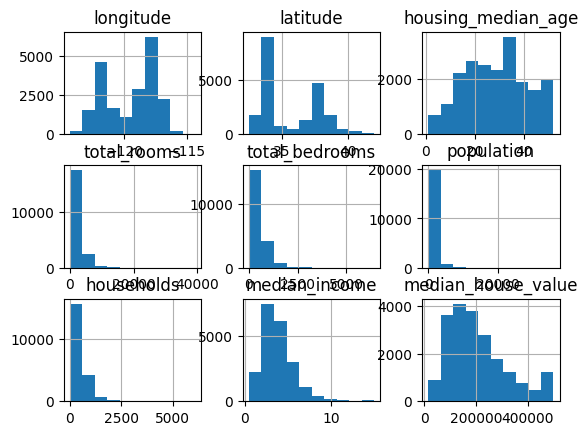

In [7]:
plt.figure(figsize=(10,6))
housing.hist()

In [8]:
X =housing.drop(columns='median_house_value')
y = housing['median_house_value']

In [9]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((16512, 9), (16512,), (4128, 9), (4128,))

In [11]:
num_column = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_column = make_pipeline(
    OneHotEncoder(handle_unknown='ignore')
)

processed = ColumnTransformer([
    ('num', num_column, make_column_selector(dtype_include=np.number)),
    ('cat', cat_column, make_column_selector(dtype_exclude=np.number))
])

In [12]:
X_train_processed = processed.fit_transform(X_train)

In [13]:
random_forest = make_pipeline(processed, RandomForestRegressor(random_state=42))
param_distrubution = {
    'randomforestregressor__max_depth' : [3,5,8],
    'randomforestregressor__min_samples_split' : [10,20,50],
    'randomforestregressor__min_samples_leaf' : [5,10,20],
    'randomforestregressor__max_features' : ['sqrt', 'log2'],
    'randomforestregressor__n_estimators' : [50,100,150]
}

randomized_search = RandomizedSearchCV(
    random_forest,
    param_distributions=param_distrubution,
    n_iter=10,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=43
)

randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestregressor__max_depth': [3, 5, ...], 'randomforestregressor__max_features': ['sqrt', 'log2'], 'randomforestregressor__min_samples_leaf': [5, 10, ...], 'randomforestregressor__min_samples_split': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits wi

In [14]:
X_test_processed = processed.transform(X_test)

In [15]:
algorithms = {"Linear Regression" : LinearRegression(), 
              "Random Forest" : RandomForestRegressor(), 
              "SVR" : SVR(), 
              "Decision Tree" : DecisionTreeRegressor(), 
              "Gradient Boosting" : GradientBoostingRegressor()}

In [16]:
results = []

In [17]:
for name, algorithm in algorithms.items():
    pipeline = make_pipeline(processed, algorithm)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_train)
    train_rmse = root_mean_squared_error(y_train, y_pred)

    cross_validation_scores = -cross_val_score(
        pipeline, X_train,y_train,cv=5, scoring="neg_root_mean_squared_error"
    )

    results.append({
        "Algorithm": name,
        "Train RMSE": train_rmse,
        "CV Mean RMSE": cross_validation_scores.mean(),
        "CV STD RMSE": cross_validation_scores.std(),
        # "CV MIM RMSE": cross_validation_scores.min(),
        # "CV MAX RMSE": cross_validation_scores.max()
    })
    results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="CV Mean RMSE")
print(results_df)


           Algorithm     Train RMSE   CV Mean RMSE  CV STD RMSE
1      Random Forest   18179.651887   49309.907069   604.049301
4  Gradient Boosting   52901.313885   55026.903387   726.008689
0  Linear Regression   68433.937367   68622.535283  1438.766616
3      Decision Tree       0.000000   70042.320806  1324.201815
2                SVR  118406.219464  118477.805940  1612.259020


In [18]:
best_algorithm = results_df.iloc[0]["Algorithm"]
best_algorithm

'Random Forest'

In [19]:
best_model_pred = model.predict(X_test)

NameError: name 'model' is not defined

In [ ]:
best_model_rmse = root_mean_squared_error(y_test, best_model_pred)
best_model_rmse

In [ ]:
joblib.dump(linear_reg, "real_estate_model.pkl")